# RAG 

- técnica amplamente utilizada na construção de chatbots
- A partir de um documento armazenado no banco de dados 
- Recuperar e gerar textos a partir de informações desse banco


### Projeto de Exemplo

- MentorCoffee: É um site desenvolvido em Django que promove mentorias, cursos e workshops para promoção de parceiros produtos e consumidores de café.

### Tecnologias 

1) Documento (.pdf)
2) site (HTML,CSS,JAVASCRIPT (Chart.JS),Django,SQLite,DjangoORM,Django Security,Django ADMIN )
3) LlamaIndex
4) Gradio: protótipo do chatbot
5) LangFlow: fluxo completo
6) HTML (Integração do CHATBOT)
7) Deploy  - PythonAnyWhere - (Vercel) - AWS
8) Python (linguagem)
9) HuggingFace

##### Vamos fazer um Hello RAG?

In [1]:
# coloque aqui o code
print("Hello rag")

Hello rag


In [4]:
# qual a versão do python que você está usando?
! python --version

Python 3.13.2


In [5]:
# já instalou o ipykernel? Se não, instale com o comando: pip install ipykernel
print("Sim")

Sim


In [6]:
# se você usa o python 3.13.7 , qual versão do LlamaIndex você está usando? Se não tiver instalado, instale com o comando: pip install llama-index

In [7]:
! pip list

Package                 Version
----------------------- -----------
asttokens               3.0.2
colorama                0.4.6
comm                    0.2.3
debugpy                 1.8.22
executing               2.2.1
ipykernel               7.3.0
ipython                 9.17.1
ipython_pygments_lexers 1.1.1
jedi                    0.20.0
jupyter_client          8.10.0
jupyter_core            5.9.1
matplotlib-inline       0.2.2
nest-asyncio2           1.7.2
packaging               26.3
parso                   0.8.7
pip                     24.3.1
platformdirs            4.11.9
prompt_toolkit          3.0.53
psutil                  7.2.2
pure_eval               0.2.4
Pygments                2.21.0
python-dateutil         2.9.0.post0
pyzmq                   27.2.0
six                     1.17.0
stack-data              0.6.3
tornado                 6.5.10
traitlets               5.16.1
typing_extensions       4.16.0
wcwidth                 0.8.3


In [8]:
! pip install -q llama-index==0.12.17 gradio==5.16.0


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
! python.exe -m pip install -q --upgrade pip

In [10]:
from llama_index.core import SimpleDirectoryReader

c:\Users\BIBLIOTECA\Desktop\aula_hoje\mentorcoffee\.venv\Lib\site-packages\pydantic\_internal\_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'validate_default' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'validate_default' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(


In [11]:
documentos = SimpleDirectoryReader(input_dir='documentos')

In [12]:
documentos.input_files

[WindowsPath('c:/Users/BIBLIOTECA/Desktop/aula_hoje/mentorcoffee/documentos/mentor_coffee_atualizado.pdf')]

In [13]:
docs = documentos.load_data()

In [14]:
docs

[Document(id_='69de637a-1cbf-4d32-8058-d29734c60ab9', embedding=None, metadata={'page_label': '1', 'file_name': 'mentor_coffee_atualizado.pdf', 'file_path': 'c:\\Users\\BIBLIOTECA\\Desktop\\aula_hoje\\mentorcoffee\\documentos\\mentor_coffee_atualizado.pdf', 'file_type': 'application/pdf', 'file_size': 229748, 'creation_date': '2026-09-16', 'last_modified_date': '2026-09-16'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text_resource=MediaResource(embeddings=None, data=None, text='MentorCoffee – Mentoria e vendas de cafés especiais  \n  \nInformações gerais  \n  \nP: Quais produtos são vendidos no site da MentorCoffee?  \nR: A MentorCoffee é uma loja online especializada na venda de grãos de cafés

In [15]:
len(docs)

10

In [16]:
print(docs[0].get_metadata_str())

page_label: 1
file_name: mentor_coffee_atualizado.pdf
file_path: c:\Users\BIBLIOTECA\Desktop\aula_hoje\mentorcoffee\documentos\mentor_coffee_atualizado.pdf
file_type: application/pdf
file_size: 229748
creation_date: 2026-09-16
last_modified_date: 2026-09-16


In [17]:
docs[0].__dict__

{'id_': '69de637a-1cbf-4d32-8058-d29734c60ab9',
 'embedding': None,
 'metadata': {'page_label': '1',
  'file_name': 'mentor_coffee_atualizado.pdf',
  'file_path': 'c:\\Users\\BIBLIOTECA\\Desktop\\aula_hoje\\mentorcoffee\\documentos\\mentor_coffee_atualizado.pdf',
  'file_type': 'application/pdf',
  'file_size': 229748,
  'creation_date': '2026-09-16',
  'last_modified_date': '2026-09-16'},
 'excluded_embed_metadata_keys': ['file_name',
  'file_type',
  'file_size',
  'creation_date',
  'last_modified_date',
  'last_accessed_date'],
 'excluded_llm_metadata_keys': ['file_name',
  'file_type',
  'file_size',
  'creation_date',
  'last_modified_date',
  'last_accessed_date'],
 'relationships': {},
 'metadata_template': '{key}: {value}',
 'metadata_separator': '\n',
 'text_resource': MediaResource(embeddings=None, data=None, text='MentorCoffee – Mentoria e vendas de cafés especiais  \n  \nInformações gerais  \n  \nP: Quais produtos são vendidos no site da MentorCoffee?  \nR: A MentorCoffee 

In [18]:
# mostre o número de páginas
print(len(docs))


10


# Aula 2 - Organizando os documentos em partes  menores

>       **Por que aplicar Chunking em RAG?**
> Dividir documentos em blocos menores (*chunks*) é essencial para otimizar a busca vetorial: em vez de varrer arquivos inteiros a cada pergunta, a
 IA localiza rapidamente apenas os trechos exatos e relevantes, aumentando a precisão das respostas, reduzindo o consumo de tokens e tornando a interação com o chatbot muito mais rápida. 

![ChatGPT Image 14 de set. de 2026, 15_03_27.png](<attachment:ChatGPT Image 14 de set. de 2026, 15_03_27.png>)
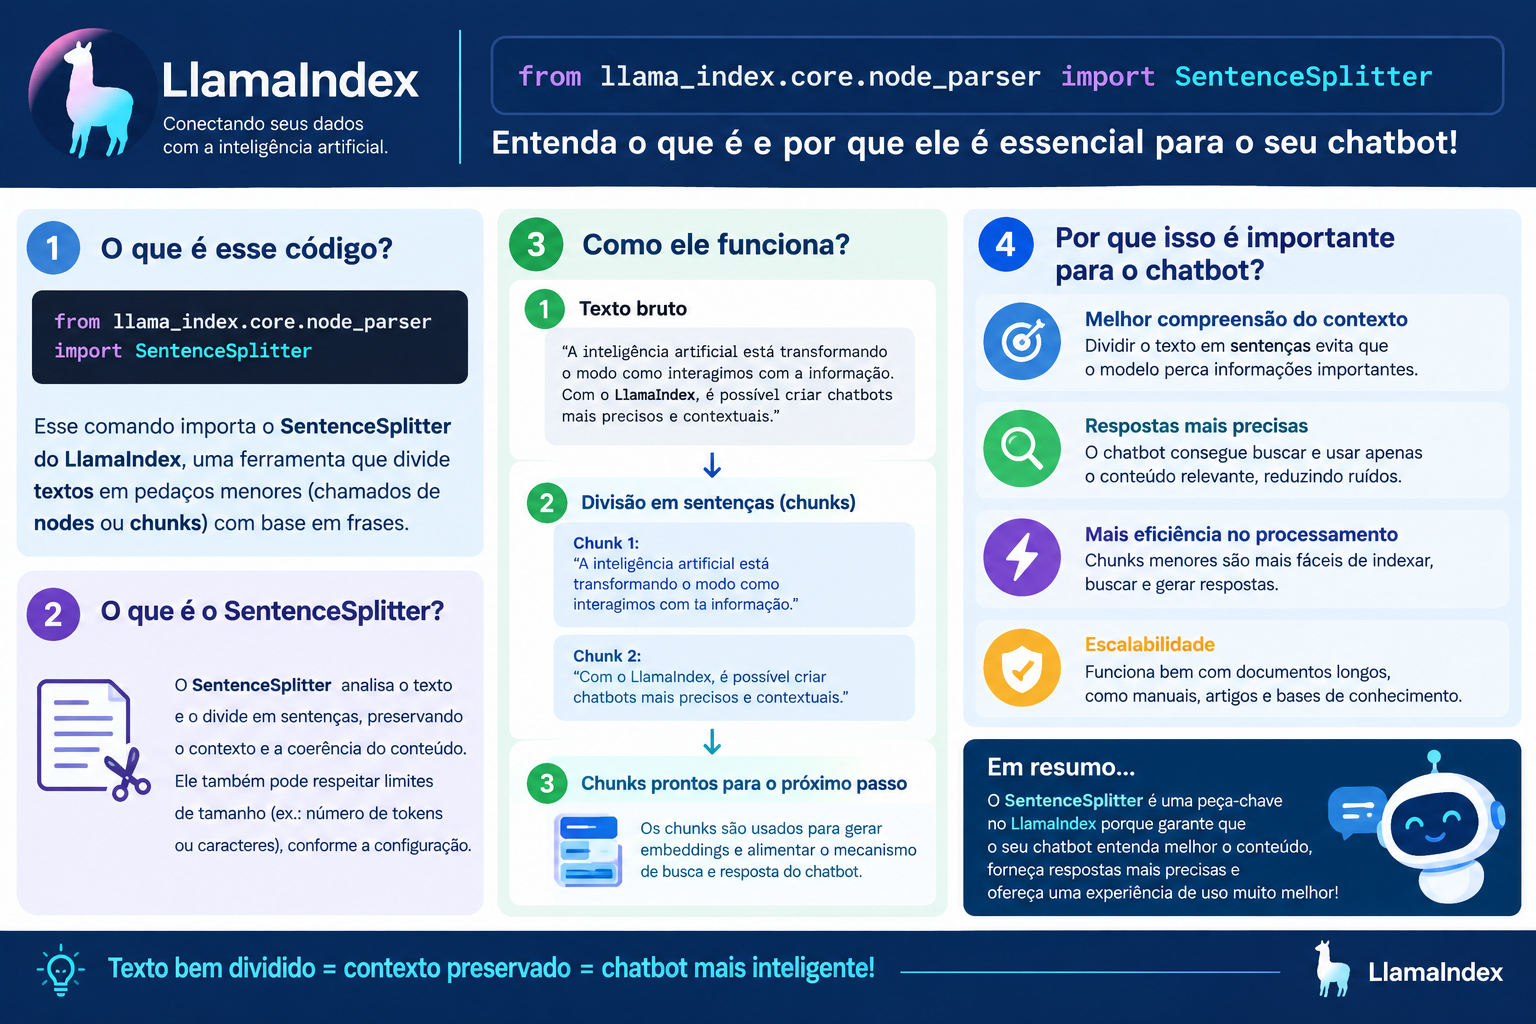

##### llama_index.core.node_parser: Módulo do LlamaIndex focado em transformar documentos em Nodes (unidades fundamentais de informação no LlamaIndex) 

In [19]:
from llama_index.core.node_parser import SentenceSplitter

###     Configurando o Divisor de Texto (`SentenceSplitter`) 
```python node_parser = SentenceSplitter(chunk_size=1200) ``` >
      **O que este código faz:** Instancia o fatiador para dividir os documentos em blocos (*nodes/chunks*) de até **1.200 caracteres** cada. >        **Objetivo:** Garante que o texto seja quebrado no tamanho ideal para ser armazenado e localizado rapidamente na busca do chatbot. 

In [20]:
node_parser = SentenceSplitter(chunk_size=1200)

###    Gerando os Blocos de Texto (`Nodes`) 

```python nodes = node_parser.get_nodes_from_documents(docs, show_progress=True) ``` >     **O que este código faz:** Executa a divisão dos documentos (`docs`) nos blocos menores pré-configurados e exibe uma barra de progresso no terminal. >        **Objetivo:** Transforma arquivos extensos em uma lista de pedaços (*nodes*) estruturados, prontos para serem salvos no banco de dados do chatbot. 

In [21]:
nodes = node_parser.get_nodes_from_documents(docs, show_progress=True)

c:\Users\BIBLIOTECA\Desktop\aula_hoje\mentorcoffee\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Parsing nodes: 100%|██████████| 10/10 [00:00<00:00, 1209.43it/s]


###            Conferindo a Quantidade de Blocos Gerados 

In [22]:
len(nodes)

10

>     **O que este código faz:** Retorna o número total de pedaços (*nodes*) criados após a divisão do documento original.

>        **Objetivo:** Permite verificar rapidamente em quantos blocos o arquivo foi fatiado e validar o resultado do processo de *chunking*. 

###     Inspecionando o Primeiro Bloco de Texto 

In [23]:
print(nodes[0])

Node ID: 20e1c445-1000-4b07-944c-54a48c70e8ae
Text: MentorCoffee – Mentoria e vendas de cafés especiais
Informações gerais      P: Quais produtos são vendidos no site da
MentorCoffee?   R: A MentorCoffee é uma loja online especializada na
venda de grãos de cafés especiais,  oferecendo grãos torrados,
provenientes de fazendas seleci onadas da região de   Brazlândia, a
produção é realizada no ...


>     **O que este código faz:** Exibe no terminal o conteúdo textual e os metadados contidos no primeiro bloco (*node*) da lista. 

>        **Objetivo:** Permite inspecionar o trecho exato e verificar se a divisão preservou o sentido e a formatação do texto. 

In [24]:
print(nodes[9])

Node ID: a90d8b7c-5880-4c37-ba7b-3379d16358d0
Text: R: Recomendamos armazenar os grãos em um rec ipiente hermético,
longe da umidade  e calor. Evite guardar o café na geladeira, pois a
umidade e as variações de temperatura  podem prejudicar o sabor e o
aroma.      P: Qual é a validade dos cafés da MentorCoffee?   R:
Nossos cafés são enviados recém -torrados pa ra garantir frescor. Para
uma  exper...


### Armazenar os Dados no Chroma DB

- Banco de Dados Local
- Voltado para a técnica de RAG

### Modelos de Embedding da Hugging Face

- Embedding é o processo transforma texto em número (formato otimizado)
- Converter o texto vetores numéricos (manter a semântica)
- Llama-index: OpenAI (processo embedding) - chaves gerar custo (pix)
- Llama-index: alternativa gratuita (usar um modelo do Hugging Face) 
- ChromaDB Não Têm Total compatibilidade Hugging Face.
   * Criar uma classe (conjunto de objetos)
   * Objeto: é uma instância de  uma classe
- Essa classe será responsável pela compatibilidade entre o Chroma DB e o Hugging Face.


- A instalação do pacote abaixo serve para utilizar modelos de embeddings do huggingface

In [25]:
! pip install -q llama-index-embeddings-huggingface

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
llama-index 0.12.17 requires llama-index-core<0.13.0,>=0.12.17, but you have llama-index-core 0.14.24 which is incompatible.
llama-index-agent-openai 0.4.8 requires llama-index-core<0.13,>=0.12.18, but you have llama-index-core 0.14.24 which is incompatible.
llama-index-cli 0.4.1 requires llama-index-core<0.13.0,>=0.12.0, but you have llama-index-core 0.14.24 which is incompatible.
llama-index-embeddings-openai 0.3.1 requires llama-index-core<0.13.0,>=0.12.0, but you have llama-index-core 0.14.24 which is incompatible.
llama-index-indices-managed-llama-cloud 0.8.0 requires llama-index-core<0.13,>=0.12.0, but you have llama-index-core 0.14.24 which is incompatible.
llama-index-llms-openai 0.3.44 requires llama-index-core<0.13,>=0.12.37, but you have llama-index-core 0.14.24 which is incompatible.
llama-index-multi-

In [26]:
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

In [84]:
class ChromaEmbeddingWrapper:
    def __init__(self,model_name):
        # inicializa o modelo de embeddings do Hugging Face com o nome especificado
        self.model = HuggingFaceEmbedding(model_name=model_name)
        # Adiciona o atributo 'name' exigido pelo ChromaDB para evitar o erro
        self.name = model_name
    def __call__(self,input): # converte a entrada para um formato compatível com o HFE.
        return self.model.embed(input)


In [85]:
# banco de dados = definindo o modelo de embedding usado pelo Chroma
embed_model_chroma = ChromaEmbeddingWrapper(model_name='intfloat/multilingual-e5-large')

Loading weights: 100%|██████████| 391/391 [00:08<00:00, 48.16it/s] 


# Instalando o banco para integrar o Chroma com um armazenamento de vetores no LlamaIndex

In [86]:
! pip install -q llama-index-vector-stores-chroma

In [80]:
# importando o ChromaDB
import chromadb

# criando um cliente persistente do ChromaDB, armazenar os dados no diretório
db = chromadb.PersistentClient(path='./chroma_db')

In [81]:
# atribuindo o cliente a uma variável para uso posterior
chroma_client = db
# definindo um nome da coleção que será criada
collection_name = 'documentos_mentor_coffee'

In [89]:
# Adicione uma string identificadora ao objeto antes do bloco try/except
# O lambda cria uma função executável em uma única linha que retorna a string esperada
embed_model_chroma.name = lambda: "modelo_de_embedding_customizado"
try:
    chroma_collection = chroma_client.get_or_create_collection(
        name = collection_name,
        embedding_function= embed_model_chroma
    )

except Exception as e:
    print(f'Erro ao carregar ou criar a coleção:{e}')

# Conclusao

- O codigo esta pronto para gerar o ChromaDB
- O Diretorio foi criado
- Nao criamos a colecao e nao fizemos o processo de embeddings

# Amanha

- Criar o embedding de todas as informacoes do mentorcoffee e inserir no banco de dados.

In [90]:
# classe para armazenamento no ChromaDB
from llama_index.vector_stores.chroma import ChromaVectorStore

In [91]:
# classe para gerenciar um armazenamento
from llama_index.core import StorageContext

In [92]:
# vector_store > passar a coleção.
vector_store = ChromaVectorStore(chroma_collection=chroma_collection)
# criar uma variável de contexto de armazenamento
# vamos passar a coleção que esta no vector_store
storage_context = StorageContext.from_defaults(vector_store=vector_store)

In [93]:
# vamos definir o modelo de embedding
embed_model = HuggingFaceEmbedding(model_name='intfloat/multilingual-e5-large')

Loading weights: 100%|██████████| 391/391 [00:02<00:00, 156.71it/s]


In [94]:
# vamos criar um índice
from llama_index.core import VectorStoreIndex
index = VectorStoreIndex(nodes,storage_context=storage_context,embed_model=embed_model)

In [95]:
# vamos carregar o indice
from llama_index.core import load_index_from_storage
index = load_index_from_storage(storage_context,embed_model=embed_model)

Esses dois blocos de código ilustram perfeitamente o ciclo de vida dos dados em um sistema de RAG (Retrieval-Augmented Generation) usando o LlamaIndex.

Para tornar a explicação bem didática, podemos fazer uma analogia com a preparação de um café de especialidade: existe o momento trabalhoso de moer o grão e preparar a extração, e o momento rápido de servir o que já está pronto na garrafa térmica.

Aqui está o que cada célula está fazendo nos bastidores:
1. Criando o Índice (A "Moagem e Preparação")

No primeiro bloco (célula 94), você está construindo a base de conhecimento do zero.

    VectorStoreIndex: É a classe responsável por organizar seus textos de uma forma que a inteligência artificial consiga pesquisar depois.

    nodes: São os seus "grãos de café". Na prática, são os blocos de texto (chunks) que já foram extraídos dos seus documentos originais (PDFs, textos, etc.) e empacotados em nós de informação.

    embed_model: É o "moedor". Ele pega cada um dos nodes (textos) e os transforma em vetores (sequências de números). É isso que permite ao sistema entender a semântica do texto (o significado) em vez de apenas buscar por palavras-chave.

    storage_context: É o seu "recipiente". Ele define onde esses vetores gerados serão salvos (por exemplo, no disco rígido do computador ou em um banco de dados vetorial como o ChromaDB que você usou anteriormente).

Note o tempo de execução (16.6s): Demora mais porque o modelo de embedding está trabalhando ativamente, lendo cada fragmento de texto, executando cálculos matemáticos pesados para vetorizar tudo e gravando no armazenamento.
2. Carregando o Índice (O "Servir Imediato")

No segundo bloco (célula 95), você já fez o trabalho duro no passado e agora só quer reutilizar os dados que guardou.

    load_index_from_storage: É a função que vai até o seu diretório ou banco de dados e "acorda" o índice que já foi construído.

    storage_context: Você passa o mesmo caminho/configuração usado na criação. É como dizer ao código: "Lembra daquela caixa onde guardamos os vetores? Vá até lá e pegue os dados."

    embed_model: Mesmo carregando dados prontos, você precisa passar o modelo de embedding novamente. O sistema precisa dele carregado na memória para conseguir traduzir a pergunta futura do usuário para a mesma linguagem matemática (vetores) que está salva no banco.

Note o tempo de execução (0.0s): É praticamente instantâneo. O código não está lendo textos nem gerando novos vetores; ele está apenas criando os "ponteiros" de memória para ler o banco de dados que já está consolidado no disco.